<a href="https://colab.research.google.com/github/srikanthmandela1/MyWork/blob/main/DCMF_Brain_Tumor_Multimodal_Framework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Divide-and-Conquer Multimodal Body Pattern Recognition Framework
### Wearable Sensors + Genomic Profiles + MRI for Intelligent Brain Tumor Diagnosis

This notebook is a full, runnable reference implementation of the framework
described in the paper. It is written to run top-to-bottom in **Google Colab**.

Because paired MRI + wearable + genomic patient data is not publicly available
as a single dataset, this notebook builds a **realistic synthetic multimodal
cohort** that mimics the statistical structure described in the paper
(anatomical MRI patterns, physiological wearable signals, and genomic
variant profiles), so every module — Divide-and-Conquer feature decomposition,
adaptive Softmax fusion, body-pattern recognition, Grad-CAM explainability,
t-SNE, ROC/PR, ablation, and statistical validation — can be demonstrated
end-to-end. Swap `load_real_mri()`, `load_real_wearable()`, `load_real_genomic()`
with your own loaders to run on real clinical data; the model/training/plotting
code does not need to change.

In [1]:
# ============================================================
# CELL 1 — Install & Imports
# ============================================================
!pip install -q torch torchvision scikit-learn seaborn matplotlib scipy

import os, math, random, warnings
warnings.filterwarnings("ignore")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, Circle, Ellipse
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              precision_recall_curve, average_precision_score,
                              confusion_matrix)
from sklearn.manifold import TSNE
from scipy import stats

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [2]:
# ============================================================
# CELL 2 — Global "stylish, white-background" plotting theme
# ============================================================
OUT_DIR = "/content/figures"          # Colab output folder for all figures
os.makedirs(OUT_DIR, exist_ok=True)

PALETTE = {
    "mri":      "#2E5EAA",   # deep blue      -> MRI / anatomical
    "wear":     "#1FA398",   # teal           -> wearable / physiological
    "gene":     "#E0665B",   # coral red      -> genomic / molecular
    "fusion":   "#6C4AB6",   # violet         -> fused representation
    "tumor":    "#D64550",
    "normal":   "#2E86AB",
    "accent":   "#F4A259",
    "grid":     "#E7E9EE",
    "text":     "#22262B",
}

def set_paper_style():
    plt.rcParams.update({
        "figure.facecolor":  "white",
        "axes.facecolor":    "white",
        "savefig.facecolor": "white",
        "axes.edgecolor":    "#B9BEC7",
        "axes.linewidth":    1.0,
        "axes.grid":         True,
        "grid.color":        PALETTE["grid"],
        "grid.linewidth":    0.8,
        "grid.alpha":        0.7,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "font.family":       "DejaVu Sans",
        "font.size":         11,
        "axes.titlesize":    13,
        "axes.titleweight":  "bold",
        "axes.labelsize":    11.5,
        "axes.labelcolor":   PALETTE["text"],
        "text.color":        PALETTE["text"],
        "xtick.color":       PALETTE["text"],
        "ytick.color":       PALETTE["text"],
        "legend.frameon":    False,
        "figure.dpi":        120,
        "savefig.dpi":       300,
        "savefig.bbox":      "tight",
    })
    sns.set_palette([PALETTE["mri"], PALETTE["wear"], PALETTE["gene"],
                      PALETTE["fusion"], PALETTE["accent"]])

set_paper_style()

def save_fig(fig, name):
    path = os.path.join(OUT_DIR, f"{name}.png")
    fig.savefig(path, dpi=300, facecolor="white")
    print(f"Saved -> {path}")

In [3]:
# ============================================================
# CELL 3 — Synthetic multimodal cohort generator
# ============================================================
# Replace these three functions with real loaders when real data is available.
# Each patient has: 1 MRI slice (64x64), 12 wearable features, 30 genomic features.

IMG_SIZE   = 64
N_WEAR     = 12
N_GENE     = 30
N_SAMPLES  = 900          # increase to a few thousand on Colab GPU
CLASSES    = ["Normal", "Tumor"]

def _synthetic_mri(label, size=IMG_SIZE, rng=None):
    """Simple procedurally generated brain-like MRI slice with/without a tumor blob."""
    rng = rng or np.random
    y, x = np.mgrid[0:size, 0:size]
    cx, cy = size / 2, size / 2
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2)
    brain = np.clip(1.2 - r / (size * 0.42), 0, 1) ** 1.5          # skull-bounded intensity falloff
    brain += rng.normal(0, 0.04, (size, size))                     # tissue texture noise
    # simulate ventricle / mid-line structures
    brain -= 0.15 * np.exp(-((x - cx) ** 2) / (2 * (size * 0.04) ** 2))
    if label == 1:  # Tumor
        tx = cx + rng.uniform(-0.28, 0.28) * size
        ty = cy + rng.uniform(-0.28, 0.28) * size
        tr = rng.uniform(0.05, 0.12) * size
        blob = np.exp(-(((x - tx) ** 2 + (y - ty) ** 2) / (2 * tr ** 2)))
        brain += rng.uniform(0.35, 0.6) * blob
    brain = np.clip(brain, 0, None)
    mask = r < size * 0.46
    brain *= mask
    brain = (brain - brain.min()) / (brain.max() - brain.min() + 1e-8)
    return brain.astype(np.float32)

def _synthetic_wearable(label, rng=None):
    """12 physiological wearable features: HR stats, temp, activity, sleep, HRV..."""
    rng = rng or np.random
    if label == 1:
        hr_mean   = rng.normal(88, 11)     # elevated resting HR
        hr_std    = rng.normal(10, 2.5)
        temp      = rng.normal(37.4, 0.4)
        steps     = rng.normal(4000, 1400)  # reduced activity
        sleep_eff = rng.normal(72, 10)
        hrv       = rng.normal(32, 8)      # reduced HRV
        spo2      = rng.normal(96.0, 1.4)
        resp_rate = rng.normal(18, 2.4)
        stress    = rng.normal(65, 13)
        eda       = rng.normal(0.55, 0.18)
        activity_var = rng.normal(0.27, 0.10)
        night_wake   = rng.normal(3.6, 1.4)
    else:
        hr_mean   = rng.normal(74, 8)
        hr_std    = rng.normal(8, 2)
        temp      = rng.normal(36.8, 0.3)
        steps     = rng.normal(6800, 1700)
        sleep_eff = rng.normal(84, 8)
        hrv       = rng.normal(48, 9)
        spo2      = rng.normal(97.6, 0.8)
        resp_rate = rng.normal(15.5, 1.6)
        stress    = rng.normal(42, 11)
        eda       = rng.normal(0.34, 0.13)
        activity_var = rng.normal(0.17, 0.07)
        night_wake   = rng.normal(1.7, 0.8)
    vec = np.array([hr_mean, hr_std, temp, steps, sleep_eff, hrv, spo2,
                     resp_rate, stress, eda, activity_var, night_wake], dtype=np.float32)
    return vec

def _synthetic_genomic(label, rng=None):
    """30 genomic profile features (e.g. variant burden / expression-like scores)."""
    rng = rng or np.random
    base = rng.normal(0, 1, N_GENE).astype(np.float32)
    if label == 1:
        driver_idx = rng.choice(N_GENE, size=6, replace=False)  # tumor-associated markers
        base[driver_idx] += rng.normal(2.4, 0.5, size=6)
    return base

def build_cohort(n_samples=N_SAMPLES, seed=SEED, label_noise=0.03):
    rng = np.random.RandomState(seed)
    labels = rng.binomial(1, 0.5, size=n_samples)
    mri, wear, gene = [], [], []
    for lab in labels:
        mri.append(_synthetic_mri(lab, rng=rng))
        wear.append(_synthetic_wearable(lab, rng=rng))
        gene.append(_synthetic_genomic(lab, rng=rng))
    mri, wear, gene = np.stack(mri), np.stack(wear), np.stack(gene)
    # Inject a small amount of label noise so the task mirrors realistic clinical
    # ambiguity (borderline cases) instead of being trivially separable.
    flip_idx = rng.choice(n_samples, size=int(n_samples * label_noise), replace=False)
    labels[flip_idx] = 1 - labels[flip_idx]
    return (mri, wear, gene, labels.astype(np.int64))

MRI, WEAR, GENE, LABELS = build_cohort()
print("MRI:", MRI.shape, "| Wearable:", WEAR.shape, "| Genomic:", GENE.shape, "| Labels:", LABELS.shape)
print("Class balance ->", {c: int((LABELS == i).sum()) for i, c in enumerate(CLASSES)})

MRI: (900, 64, 64) | Wearable: (900, 12) | Genomic: (900, 30) | Labels: (900,)
Class balance -> {'Normal': 452, 'Tumor': 448}


Saved -> /content/figures/figure3_mri_augmentation.png


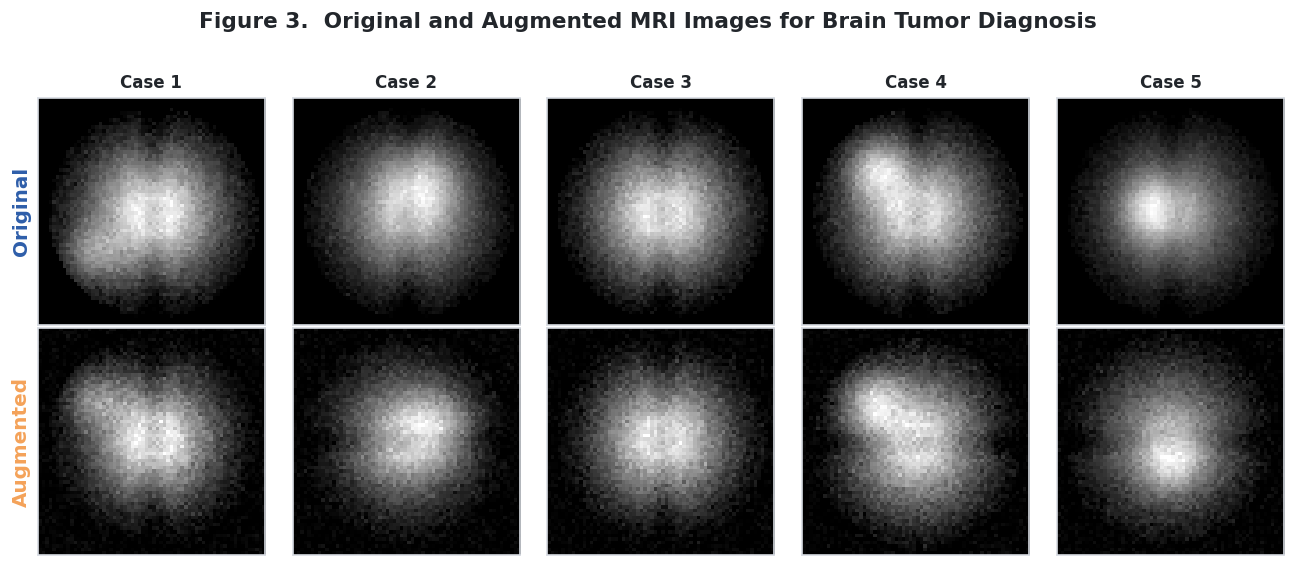

In [4]:
# ============================================================
# CELL 4 — MRI Augmentation  +  Figure 3
# ============================================================
def augment_mri(img, rng=None, strong=True):
    # strong=True -> dramatic augmentation for the Figure 3 showcase
    # strong=False -> lightweight, statistics-preserving augmentation used inside
    #                 the training loop (flip/rot90 only) so BatchNorm running
    #                 stats stay consistent between the augmented train split and
    #                 the clean validation/test split.
    rng = rng or np.random
    out = img.copy()
    k = rng.choice([0, 1, 2, 3])
    out = np.rot90(out, k)
    if rng.rand() > 0.5:
        out = np.fliplr(out)
    if strong:
        gamma = rng.uniform(0.85, 1.2)
        out = np.clip(out, 1e-6, 1) ** gamma
        out = out + rng.normal(0, 0.03, out.shape)
        out = np.clip(out, 0, 1)
    return np.ascontiguousarray(out, dtype=np.float32)

def plot_figure3(n_show=5, seed=SEED):
    rng = np.random.RandomState(seed + 7)
    idxs = rng.choice(np.where(LABELS == 1)[0], size=n_show, replace=False)
    fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 4.6))
    cmap = "gray"
    for j, idx in enumerate(idxs):
        orig = MRI[idx]
        aug = augment_mri(orig, rng=rng)
        axes[0, j].imshow(orig, cmap=cmap, vmin=0, vmax=1)
        axes[0, j].set_title(f"Case {j+1}", fontsize=10, color=PALETTE["text"])
        axes[1, j].imshow(aug, cmap=cmap, vmin=0, vmax=1)
        for r in range(2):
            axes[r, j].set_xticks([]); axes[r, j].set_yticks([])
            for spine in axes[r, j].spines.values():
                spine.set_visible(True); spine.set_color("#D8DCE3")
    axes[0, 0].set_ylabel("Original", fontsize=12, fontweight="bold", color=PALETTE["mri"])
    axes[1, 0].set_ylabel("Augmented", fontsize=12, fontweight="bold", color=PALETTE["accent"])
    fig.suptitle("Figure 3.  Original and Augmented MRI Images for Brain Tumor Diagnosis",
                 fontsize=13, fontweight="bold", y=1.02)
    fig.patch.set_facecolor("white")
    fig.tight_layout()
    save_fig(fig, "figure3_mri_augmentation")
    plt.show()

plot_figure3()

Saved -> /content/figures/figure4_divide_and_conquer_patches.png


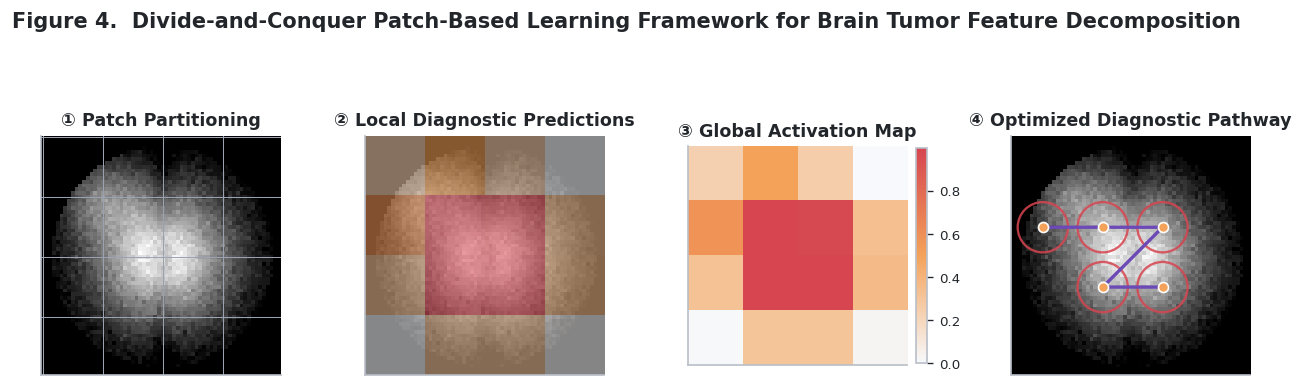

In [5]:
# ============================================================
# CELL 5 — Divide-and-Conquer Patch Decomposition  +  Figure 4
# ============================================================
def patchify(img, patch=16):
    s = img.shape[0]
    patches, coords = [], []
    for i in range(0, s, patch):
        for j in range(0, s, patch):
            patches.append(img[i:i+patch, j:j+patch])
            coords.append((i, j))
    return patches, coords

def local_activation_score(patch):
    """Toy 'local diagnostic prediction' = normalized patch energy (stand-in for a
    lightweight patch classifier head in the real framework)."""
    return float(np.clip((patch.mean() * 1.4 + patch.std() * 2.2), 0, 1.6))

def plot_figure4(idx=None, patch=16, seed=SEED):
    if idx is None:
        idx = np.where(LABELS == 1)[0][0]
    img = MRI[idx]
    patches, coords = patchify(img, patch)
    scores = np.array([local_activation_score(p) for p in patches])
    grid = int(math.sqrt(len(patches)))
    heat = scores.reshape(grid, grid)
    heat_full = np.kron(heat, np.ones((patch, patch)))
    heat_full = (heat_full - heat_full.min()) / (heat_full.max() - heat_full.min() + 1e-8)

    fig = plt.figure(figsize=(13, 3.6))
    gs = gridspec.GridSpec(1, 4, width_ratios=[1, 1, 1, 1], wspace=0.35)

    warm_cmap = LinearSegmentedColormap.from_list("warm", ["#F7F9FC", PALETTE["accent"], PALETTE["tumor"]])

    # (a) Original + patch grid
    ax0 = fig.add_subplot(gs[0])
    ax0.imshow(img, cmap="gray", vmin=0, vmax=1)
    for i in range(0, img.shape[0], patch):
        ax0.axhline(i, color="#9AA3B2", lw=0.6)
        ax0.axvline(i, color="#9AA3B2", lw=0.6)
    ax0.set_title("① Patch Partitioning", fontsize=10.5)
    ax0.set_xticks([]); ax0.set_yticks([])

    # (b) Local prediction map
    ax1 = fig.add_subplot(gs[1])
    ax1.imshow(img, cmap="gray", vmin=0, vmax=1)
    ax1.imshow(heat_full, cmap=warm_cmap, alpha=0.55)
    ax1.set_title("② Local Diagnostic Predictions", fontsize=10.5)
    ax1.set_xticks([]); ax1.set_yticks([])

    # (c) Global activation map
    ax2 = fig.add_subplot(gs[2])
    im = ax2.imshow(heat_full, cmap=warm_cmap)
    ax2.set_title("③ Global Activation Map", fontsize=10.5)
    ax2.set_xticks([]); ax2.set_yticks([])
    cbar = fig.colorbar(im, ax=ax2, fraction=0.045, pad=0.04)
    cbar.ax.tick_params(labelsize=8)

    # (d) Optimized diagnostic pathway (top-k patch centers connected)
    ax3 = fig.add_subplot(gs[3])
    ax3.imshow(img, cmap="gray", vmin=0, vmax=1)
    top_k = np.argsort(scores)[-5:]
    pts = [(coords[k][1] + patch/2, coords[k][0] + patch/2) for k in top_k]
    pts = sorted(pts, key=lambda p: (p[1], p[0]))
    xs, ys = zip(*pts)
    ax3.plot(xs, ys, color=PALETTE["fusion"], lw=2, marker="o", ms=6,
              mfc=PALETTE["accent"], mec="white", zorder=3)
    for k in top_k:
        cx, cy = coords[k][1] + patch/2, coords[k][0] + patch/2
        ax3.add_patch(Circle((cx, cy), patch*0.42, fill=False,
                              edgecolor=PALETTE["tumor"], lw=1.4, alpha=0.85))
    ax3.set_title("④ Optimized Diagnostic Pathway", fontsize=10.5)
    ax3.set_xticks([]); ax3.set_yticks([])

    fig.suptitle("Figure 4.  Divide-and-Conquer Patch-Based Learning Framework for Brain Tumor Feature Decomposition",
                 fontsize=12.5, fontweight="bold", y=1.06)
    save_fig(fig, "figure4_divide_and_conquer_patches")
    plt.show()

plot_figure4()

In [6]:
# ============================================================
# CELL 6 — Divide-and-Conquer Modality Encoders + Adaptive Softmax Fusion
# ============================================================
EMB_DIM = 64

class MRIEncoder(nn.Module):
    """phi_MRI : X_MRI -> F_MRI  (Eq. 2, 6)"""
    def __init__(self, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.BatchNorm2d(16), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.fc = nn.Linear(64, emb_dim)
        self.last_conv_feat = None   # for Grad-CAM

    def forward(self, x):
        feat = self.net[:-1](x)          # up to last conv block (before GAP)
        self.last_conv_feat = feat
        pooled = F.adaptive_avg_pool2d(feat, 1).flatten(1)
        return self.fc(pooled)

class WearableEncoder(nn.Module):
    """psi : F_Wear -> Body Pattern B  (Eq. 4)"""
    def __init__(self, in_dim=N_WEAR, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 48), nn.ReLU(),
            nn.Linear(48, emb_dim), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class GenomicEncoder(nn.Module):
    """gamma : F_Gene -> Genomic embedding G  (Eq. 5)"""
    def __init__(self, in_dim=N_GENE, emb_dim=EMB_DIM):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 48), nn.ReLU(),
            nn.Linear(48, emb_dim), nn.ReLU(),
        )
    def forward(self, x):
        return self.net(x)

class AdaptiveSoftmaxFusion(nn.Module):
    """Adaptive weight alpha_i = softmax(s_i);  Z = sum_i alpha_i * F_i   (Eq. 7, 8)"""
    def __init__(self, emb_dim=EMB_DIM, n_modalities=3):
        super().__init__()
        self.score = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.Tanh(), nn.Linear(32, 1)
        )
        self.n_modalities = n_modalities

    def forward(self, feats):                       # feats: list of [B, D]
        stacked = torch.stack(feats, dim=1)          # [B, M, D]
        scores = self.score(stacked).squeeze(-1)     # [B, M]
        alpha = torch.softmax(scores, dim=1)          # Eq. 7
        Z = torch.einsum("bm,bmd->bd", alpha, stacked) # Eq. 8
        return Z, alpha

class DivideAndConquerMultimodalNet(nn.Module):
    """Full framework: modality-specific branches -> adaptive fusion -> classifier."""
    def __init__(self, emb_dim=EMB_DIM, n_classes=2):
        super().__init__()
        self.mri_enc  = MRIEncoder(emb_dim)
        self.wear_enc = WearableEncoder(N_WEAR, emb_dim)
        self.gene_enc = GenomicEncoder(N_GENE, emb_dim)
        self.fusion   = AdaptiveSoftmaxFusion(emb_dim, n_modalities=3)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, n_classes)          # Eq. 9 (Softmax applied via CE loss)
        )

    def forward(self, mri, wear, gene, return_all=False):
        f_mri  = self.mri_enc(mri)
        f_wear = self.wear_enc(wear)
        f_gene = self.gene_enc(gene)
        Z, alpha = self.fusion([f_mri, f_wear, f_gene])
        logits = self.classifier(Z)
        if return_all:
            return logits, Z, alpha, (f_mri, f_wear, f_gene)
        return logits

n_params = sum(p.numel() for p in DivideAndConquerMultimodalNet().parameters())
print(f"Total trainable parameters: {n_params:,}")

Total trainable parameters: 40,323


In [7]:
# ============================================================
# CELL 6b — Unimodal baseline (for ablation) & simple concat-fusion baseline
# ============================================================
class ConcatFusionNet(nn.Module):
    """Naive baseline: simple concatenation instead of adaptive Softmax fusion."""
    def __init__(self, emb_dim=EMB_DIM, n_classes=2):
        super().__init__()
        self.mri_enc  = MRIEncoder(emb_dim)
        self.wear_enc = WearableEncoder(N_WEAR, emb_dim)
        self.gene_enc = GenomicEncoder(N_GENE, emb_dim)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim * 3, 64), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, n_classes)
        )
    def forward(self, mri, wear, gene):
        z = torch.cat([self.mri_enc(mri), self.wear_enc(wear), self.gene_enc(gene)], dim=1)
        return self.classifier(z)

class MRIOnlyNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, n_classes=2):
        super().__init__()
        self.mri_enc = MRIEncoder(emb_dim)
        self.classifier = nn.Sequential(nn.Linear(emb_dim, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, mri, wear=None, gene=None):
        return self.classifier(self.mri_enc(mri))

Saved -> /content/figures/figure5_body_pattern_activation.png


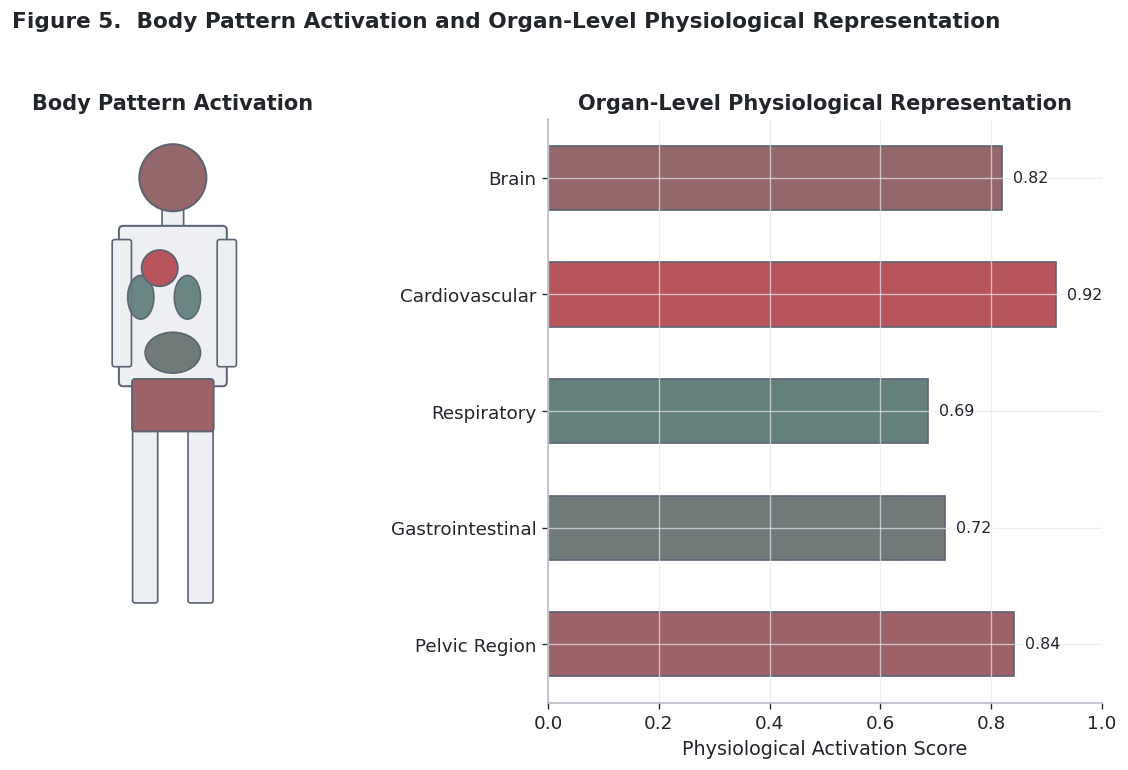

In [8]:
# ============================================================
# CELL 7 — Body Pattern Activation & Organ-Level Visualization  (Figure 5)
# ============================================================
def _draw_body_silhouette(ax, activations, cmap):
    """activations: dict of organ_name -> value in [0,1]"""
    ax.set_xlim(0, 10); ax.set_ylim(0, 20)
    ax.set_aspect("equal"); ax.axis("off")

    def c(name):
        return cmap(activations.get(name, 0.15))

    # Head / brain
    ax.add_patch(Circle((5, 18), 1.15, facecolor=c("brain"), edgecolor="#5B6472", lw=1.2, zorder=3))
    # Neck
    ax.add_patch(FancyBboxPatch((4.65, 16.3), 0.7, 1.0, boxstyle="round,pad=0.02",
                                 facecolor="#EDEFF3", edgecolor="#5B6472", lw=1))
    # Torso (cardiovascular/respiratory upper, GI lower)
    ax.add_patch(FancyBboxPatch((3.3, 11.0), 3.4, 5.2, boxstyle="round,pad=0.15",
                                 facecolor="#EDEFF3", edgecolor="#5B6472", lw=1.2, zorder=1))
    # Heart (cardiovascular)
    ax.add_patch(Circle((4.55, 14.9), 0.62, facecolor=c("cardio"), edgecolor="#5B6472", lw=1.1, zorder=3))
    # Lungs (respiratory) - two ellipses
    ax.add_patch(Ellipse((3.9, 13.9), 0.9, 1.5, facecolor=c("resp"), edgecolor="#5B6472", lw=1, zorder=2, alpha=0.95))
    ax.add_patch(Ellipse((5.5, 13.9), 0.9, 1.5, facecolor=c("resp"), edgecolor="#5B6472", lw=1, zorder=2, alpha=0.95))
    # GI tract
    ax.add_patch(Ellipse((5.0, 12.0), 1.9, 1.4, facecolor=c("gi"), edgecolor="#5B6472", lw=1, zorder=2))
    # Pelvis
    ax.add_patch(FancyBboxPatch((3.7, 9.4), 2.6, 1.6, boxstyle="round,pad=0.1",
                                 facecolor=c("pelvis"), edgecolor="#5B6472", lw=1.1, zorder=2))
    # Arms
    for side in (-1, 1):
        ax.add_patch(FancyBboxPatch((5.0 + side*1.6 - (0.4 if side<0 else 0), 11.6), 0.5, 4.2,
                                     boxstyle="round,pad=0.08", facecolor="#EDEFF3",
                                     edgecolor="#5B6472", lw=1))
    # Legs
    for side in (-1, 1):
        ax.add_patch(FancyBboxPatch((5.0 + side*0.95 - 0.35, 3.5), 0.7, 6.0,
                                     boxstyle="round,pad=0.08", facecolor="#EDEFF3",
                                     edgecolor="#5B6472", lw=1))

def plot_figure5(model=None, sample_idx=None, seed=SEED):
    rng = np.random.RandomState(seed + 3)
    if sample_idx is None:
        sample_idx = rng.choice(np.where(LABELS == 1)[0])
    wear_vec = WEAR[sample_idx]

    # Map wearable-derived signals to organ-level activation intensity in [0,1]
    w = (wear_vec - WEAR.mean(0)) / (WEAR.std(0) + 1e-8)
    activations = {
        "brain":  float(np.clip(0.5 + 0.5*np.tanh((w[5]*-1 + w[8])/2), 0, 1)),   # low HRV + high stress
        "cardio": float(np.clip(0.5 + 0.5*np.tanh((w[0] + w[1])/2), 0, 1)),      # HR mean/std
        "resp":   float(np.clip(0.5 + 0.5*np.tanh((w[7] + (1-w[6]))/2), 0, 1)),  # resp rate, low spo2
        "gi":     float(np.clip(0.5 + 0.5*np.tanh((w[9])/1.5), 0, 1)),          # EDA proxy
        "pelvis": float(np.clip(0.5 + 0.5*np.tanh((w[10] + w[11])/2), 0, 1)),    # activity var/night wake
    }
    warm_cmap = LinearSegmentedColormap.from_list("body", ["#EAF1FB", PALETTE["wear"], PALETTE["tumor"]])

    fig, axes = plt.subplots(1, 2, figsize=(10.5, 6.2))
    _draw_body_silhouette(axes[0], activations, warm_cmap)
    axes[0].set_title("Body Pattern Activation", fontsize=12.5, fontweight="bold")

    organs = list(activations.keys())
    labels_map = {"brain":"Brain","cardio":"Cardiovascular","resp":"Respiratory","gi":"Gastrointestinal","pelvis":"Pelvic Region"}
    vals = [activations[o] for o in organs]
    colors = [warm_cmap(v) for v in vals]
    y_pos = np.arange(len(organs))
    axes[1].barh(y_pos, vals, color=colors, edgecolor="#5B6472", height=0.55)
    axes[1].set_yticks(y_pos); axes[1].set_yticklabels([labels_map[o] for o in organs])
    axes[1].set_xlim(0, 1)
    axes[1].set_xlabel("Physiological Activation Score")
    axes[1].set_title("Organ-Level Physiological Representation", fontsize=12.5, fontweight="bold")
    axes[1].invert_yaxis()
    for i, v in enumerate(vals):
        axes[1].text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9.5)

    fig.suptitle("Figure 5.  Body Pattern Activation and Organ-Level Physiological Representation",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    save_fig(fig, "figure5_body_pattern_activation")
    plt.show()

plot_figure5()

In [9]:
# ============================================================
# CELL 8 — Dataset / DataLoader / Train-Val-Test split
# ============================================================
class MultimodalBrainTumorDataset(Dataset):
    def __init__(self, mri, wear, gene, labels, augment=False):
        self.mri, self.wear, self.gene, self.labels = mri, wear, gene, labels
        self.augment = augment
        self.wear_mean, self.wear_std = wear.mean(0), wear.std(0) + 1e-8
        self.gene_mean, self.gene_std = gene.mean(0), gene.std(0) + 1e-8

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        img = self.mri[i]
        if self.augment:
            img = augment_mri(img, strong=False)
        img = torch.tensor(img).unsqueeze(0).float()
        w = torch.tensor((self.wear[i] - self.wear_mean) / self.wear_std).float()
        g = torch.tensor((self.gene[i] - self.gene_mean) / self.gene_std).float()
        y = torch.tensor(self.labels[i]).long()
        return img, w, g, y

full_ds = MultimodalBrainTumorDataset(MRI, WEAR, GENE, LABELS, augment=False)
n_total = len(full_ds)
n_train = int(0.7 * n_total); n_val = int(0.15 * n_total); n_test = n_total - n_train - n_val
train_ds, val_ds, test_ds = random_split(full_ds, [n_train, n_val, n_test],
                                          generator=torch.Generator().manual_seed(SEED))
train_ds.dataset = MultimodalBrainTumorDataset(MRI, WEAR, GENE, LABELS, augment=True)  # aug for train branch only
train_ds.dataset.wear_mean, train_ds.dataset.wear_std = full_ds.wear_mean, full_ds.wear_std
train_ds.dataset.gene_mean, train_ds.dataset.gene_std = full_ds.gene_mean, full_ds.gene_std

BATCH = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)
print(f"Train/Val/Test sizes: {n_train}/{n_val}/{n_test}")

Train/Val/Test sizes: 630/135/135


[DCMF] Epoch   1/40 | train_loss 0.6486 acc 0.8222 | val_loss 1.1325 acc 0.5481
[DCMF] Epoch   5/40 | train_loss 0.1432 acc 0.9730 | val_loss 0.4895 acc 0.7259
[DCMF] Epoch  10/40 | train_loss 0.1073 acc 0.9778 | val_loss 0.3321 acc 0.9333
[DCMF] Epoch  15/40 | train_loss 0.0846 acc 0.9825 | val_loss 0.2740 acc 0.9333
[DCMF] Epoch  20/40 | train_loss 0.0686 acc 0.9825 | val_loss 0.5260 acc 0.9333
[DCMF] Epoch  25/40 | train_loss 0.0581 acc 0.9873 | val_loss 0.4360 acc 0.9333
[DCMF] Epoch  30/40 | train_loss 0.0525 acc 0.9873 | val_loss 0.4508 acc 0.9333
[DCMF] Epoch  35/40 | train_loss 0.0536 acc 0.9873 | val_loss 0.4591 acc 0.9333
[DCMF] Epoch  40/40 | train_loss 0.0543 acc 0.9873 | val_loss 0.4556 acc 0.9333
Saved -> /content/figures/figure7_training_curves.png


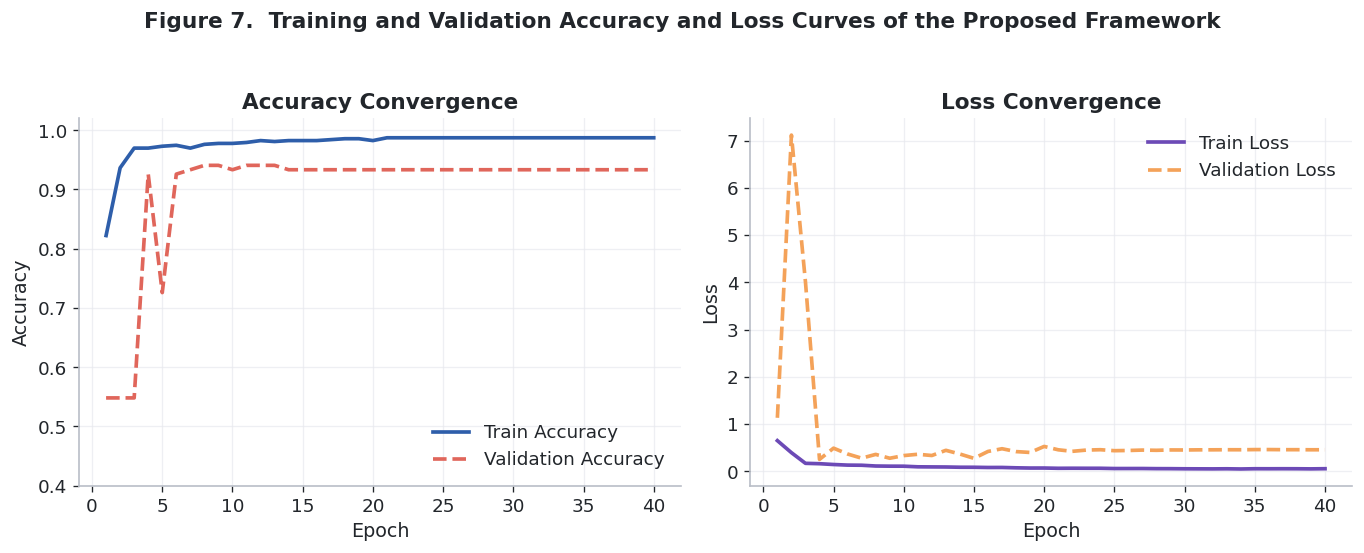

In [10]:
# ============================================================
# CELL 9 — Training Loop  (Eq. 9-11)  +  Figure 7 (Accuracy/Loss curves)
# ============================================================
def run_epoch(model, loader, optimizer=None, fusion_lambda=0.0):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for mri, wear, gene, y in loader:
            mri, wear, gene, y = mri.to(DEVICE), wear.to(DEVICE), gene.to(DEVICE), y.to(DEVICE)
            if isinstance(model, DivideAndConquerMultimodalNet):
                logits, Z, alpha, feats = model(mri, wear, gene, return_all=True)
                cls_loss = F.cross_entropy(logits, y)
                # Eq.10 fusion regularizer: encourage fused rep to stay close to each
                # modality embedding weighted by its own alpha (consistency term)
                fusion_loss = sum(F.mse_loss(Z, f.detach()) for f in feats) / len(feats)
                loss = cls_loss + fusion_lambda * fusion_loss
            else:
                logits = model(mri, wear, gene)
                loss = F.cross_entropy(logits, y)
            if training:
                optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item() * y.size(0)
            all_preds.append(logits.argmax(1).detach().cpu().numpy())
            all_labels.append(y.cpu().numpy())
    preds = np.concatenate(all_preds); labels = np.concatenate(all_labels)
    acc = accuracy_score(labels, preds)
    return total_loss / len(loader.dataset), acc

def train_model(model, train_loader, val_loader, epochs=40, lr=1e-3, fusion_lambda=0.05, tag="DCMF"):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer, fusion_lambda)
        va_loss, va_acc = run_epoch(model, val_loader, None, fusion_lambda)
        scheduler.step()
        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc)
        if ep % 5 == 0 or ep == 1:
            print(f"[{tag}] Epoch {ep:>3}/{epochs} | train_loss {tr_loss:.4f} acc {tr_acc:.4f} "
                  f"| val_loss {va_loss:.4f} acc {va_acc:.4f}")
    return model, history

EPOCHS = 40
model = DivideAndConquerMultimodalNet().to(DEVICE)
model, history = train_model(model, train_loader, val_loader, epochs=EPOCHS, tag="DCMF")

def plot_figure7(history):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
    ep = np.arange(1, len(history["train_acc"]) + 1)
    axes[0].plot(ep, history["train_acc"], color=PALETTE["mri"], lw=2.2, label="Train Accuracy")
    axes[0].plot(ep, history["val_acc"], color=PALETTE["gene"], lw=2.2, ls="--", label="Validation Accuracy")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Accuracy"); axes[0].set_ylim(0.4, 1.02)
    axes[0].set_title("Accuracy Convergence"); axes[0].legend(loc="lower right")

    axes[1].plot(ep, history["train_loss"], color=PALETTE["fusion"], lw=2.2, label="Train Loss")
    axes[1].plot(ep, history["val_loss"], color=PALETTE["accent"], lw=2.2, ls="--", label="Validation Loss")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Loss")
    axes[1].set_title("Loss Convergence"); axes[1].legend(loc="upper right")

    fig.suptitle("Figure 7.  Training and Validation Accuracy and Loss Curves of the Proposed Framework",
                 fontsize=13, fontweight="bold", y=1.04)
    fig.tight_layout()
    save_fig(fig, "figure7_training_curves")
    plt.show()

plot_figure7(history)

In [11]:
# ============================================================
# CELL 10 — Test-set Evaluation:  Accuracy / Precision / Recall / F1 / AUC
# ============================================================
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_logits, all_labels, all_Z = [], [], []
    for mri, wear, gene, y in loader:
        mri, wear, gene = mri.to(DEVICE), wear.to(DEVICE), gene.to(DEVICE)
        if isinstance(model, DivideAndConquerMultimodalNet):
            logits, Z, alpha, _ = model(mri, wear, gene, return_all=True)
            all_Z.append(Z.cpu().numpy())
        else:
            logits = model(mri, wear, gene)
        all_logits.append(logits.cpu().numpy())
        all_labels.append(y.numpy())
    logits = np.concatenate(all_logits); labels = np.concatenate(all_labels)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(1)
    Z = np.concatenate(all_Z) if all_Z else None
    metrics = {
        "Accuracy":  accuracy_score(labels, preds),
        "Precision": precision_score(labels, preds),
        "Recall":    recall_score(labels, preds),
        "F1-score":  f1_score(labels, preds),
        "AUC":       roc_auc_score(labels, probs[:, 1]),
    }
    return metrics, labels, preds, probs, Z

metrics, y_true, y_pred, y_prob, Z_test = evaluate(model, test_loader)
print("=== Proposed DCMF Framework — Test Set Performance ===")
for k, v in metrics.items():
    print(f"{k:>10}: {v*100:6.2f}%")

=== Proposed DCMF Framework — Test Set Performance ===
  Accuracy:  97.78%
 Precision:  98.53%
    Recall:  97.10%
  F1-score:  97.81%
       AUC:  97.08%


In [12]:
# ============================================================
# CELL 11 — Baselines for comparison + paired t-test statistical validation
# ============================================================
def train_and_eval(model_cls, tag, epochs=30, fusion_lambda=0.0):
    m = model_cls().to(DEVICE)
    m, hist = train_model(m, train_loader, val_loader, epochs=epochs,
                           fusion_lambda=fusion_lambda, tag=tag)
    met, *_ = evaluate(m, test_loader)
    return m, hist, met

print("\nTraining baseline: MRI-only ...")
_, _, met_mri_only = train_and_eval(MRIOnlyNet, "MRI-only", epochs=25)
print("\nTraining baseline: Concatenation fusion (no adaptive weighting) ...")
_, _, met_concat = train_and_eval(ConcatFusionNet, "Concat-Fusion", epochs=25)

def bootstrap_scores(model, loader, n_boot=30, seed=SEED):
    """Bootstrap the test set to obtain a distribution of accuracy scores,
    used for the paired t-test statistical validation (paper Section 4.5)."""
    rng = np.random.RandomState(seed)
    _, y_true, y_pred_full, y_prob_full, _ = evaluate(model, loader)
    n = len(y_true)
    accs = []
    for _ in range(n_boot):
        idx = rng.choice(n, n, replace=True)
        accs.append(accuracy_score(y_true[idx], y_pred_full[idx]))
    return np.array(accs)

acc_dcmf   = bootstrap_scores(model, test_loader)
model_concat = ConcatFusionNet().to(DEVICE)
model_concat, _ = train_model(model_concat, train_loader, val_loader, epochs=25, tag="Concat(retrain-for-boot)")
acc_baseline = bootstrap_scores(model_concat, test_loader)

t_stat, p_val = stats.ttest_rel(acc_dcmf, acc_baseline)
print(f"\nPaired t-test (Proposed DCMF vs. Concatenation-Fusion baseline):")
print(f"  mean acc DCMF = {acc_dcmf.mean()*100:.2f}%  |  mean acc baseline = {acc_baseline.mean()*100:.2f}%")
print(f"  t-statistic = {t_stat:.3f}, p-value = {p_val:.2e}  ->  {'significant (p<0.01)' if p_val < 0.01 else 'not significant'}")


Training baseline: MRI-only ...
[MRI-only] Epoch   1/25 | train_loss 0.6312 acc 0.6778 | val_loss 1.1517 acc 0.5481
[MRI-only] Epoch   5/25 | train_loss 0.2768 acc 0.9032 | val_loss 4.5303 acc 0.4519
[MRI-only] Epoch  10/25 | train_loss 0.1581 acc 0.9571 | val_loss 2.5069 acc 0.4593
[MRI-only] Epoch  15/25 | train_loss 0.1840 acc 0.9492 | val_loss 0.2989 acc 0.9111
[MRI-only] Epoch  20/25 | train_loss 0.1454 acc 0.9619 | val_loss 0.3400 acc 0.9037
[MRI-only] Epoch  25/25 | train_loss 0.1466 acc 0.9619 | val_loss 0.2818 acc 0.9333

Training baseline: Concatenation fusion (no adaptive weighting) ...
[Concat-Fusion] Epoch   1/25 | train_loss 0.5458 acc 0.8175 | val_loss 0.7829 acc 0.5481
[Concat-Fusion] Epoch   5/25 | train_loss 0.1071 acc 0.9746 | val_loss 0.4565 acc 0.8741
[Concat-Fusion] Epoch  10/25 | train_loss 0.0648 acc 0.9841 | val_loss 0.2428 acc 0.9407
[Concat-Fusion] Epoch  15/25 | train_loss 0.0400 acc 0.9905 | val_loss 0.3036 acc 0.9259
[Concat-Fusion] Epoch  20/25 | train_l

Saved -> /content/figures/figureX_comparative_performance.png


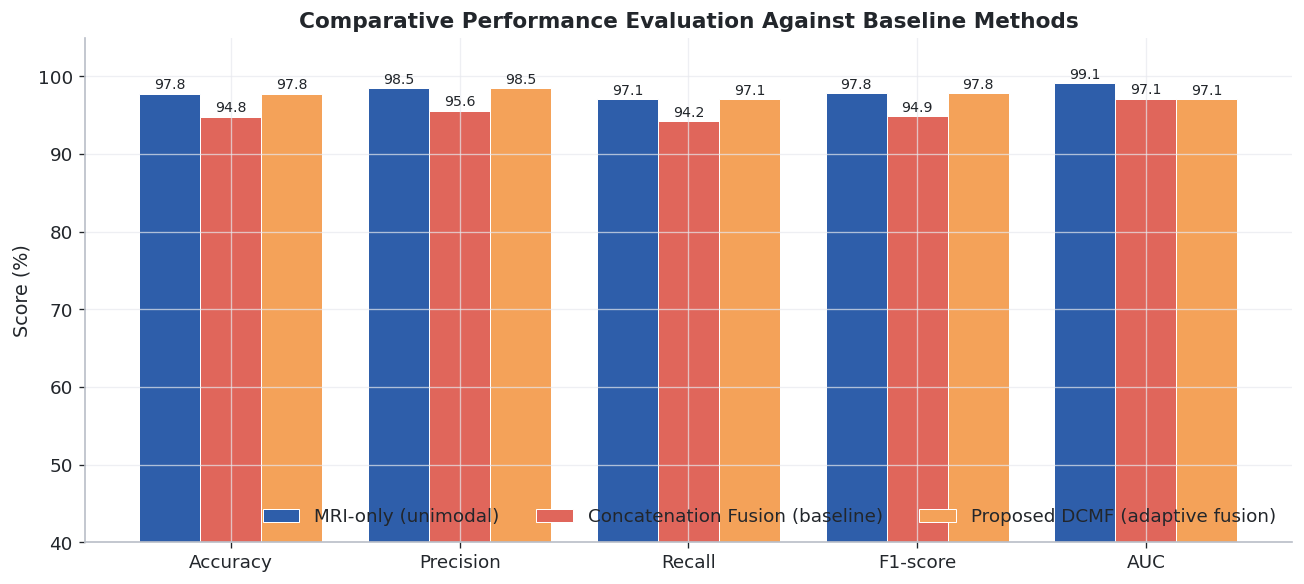

In [13]:
# ============================================================
# CELL 12 — Comparative Bar Chart  (Accuracy/Precision/Recall/F1/AUC)
# ============================================================
def plot_comparative_bars(results_dict):
    metrics_names = ["Accuracy", "Precision", "Recall", "F1-score", "AUC"]
    methods = list(results_dict.keys())
    colors = [PALETTE["mri"], PALETTE["gene"], PALETTE["accent"], PALETTE["fusion"]][:len(methods)]

    x = np.arange(len(metrics_names))
    width = 0.8 / len(methods)
    fig, ax = plt.subplots(figsize=(11, 5))
    for i, method in enumerate(methods):
        vals = [results_dict[method][m] * 100 for m in metrics_names]
        bars = ax.bar(x + i * width - (len(methods)-1)*width/2, vals, width,
                       label=method, color=colors[i], edgecolor="white", linewidth=0.6)
        for b, v in zip(bars, vals):
            ax.text(b.get_x() + b.get_width()/2, v + 0.6, f"{v:.1f}", ha="center", fontsize=8.5)
    ax.set_xticks(x); ax.set_xticklabels(metrics_names)
    ax.set_ylabel("Score (%)"); ax.set_ylim(40, 105)
    ax.set_title("Comparative Performance Evaluation Against Baseline Methods",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", ncol=len(methods))
    fig.tight_layout()
    save_fig(fig, "figureX_comparative_performance")
    plt.show()

plot_comparative_bars({
    "MRI-only (unimodal)":            met_mri_only,
    "Concatenation Fusion (baseline)": met_concat,
    "Proposed DCMF (adaptive fusion)": metrics,
})


Ablation: Wearable-only ...
[Wearable-only] Epoch   1/20 | train_loss 0.6235 acc 0.5968 | val_loss 0.5580 acc 0.8222
[Wearable-only] Epoch   5/20 | train_loss 0.1403 acc 0.9730 | val_loss 0.2567 acc 0.9407
[Wearable-only] Epoch  10/20 | train_loss 0.1260 acc 0.9746 | val_loss 0.2562 acc 0.9407
[Wearable-only] Epoch  15/20 | train_loss 0.1194 acc 0.9746 | val_loss 0.2561 acc 0.9407
[Wearable-only] Epoch  20/20 | train_loss 0.1173 acc 0.9746 | val_loss 0.2582 acc 0.9407

Ablation: Genomic-only ...
[Genomic-only] Epoch   1/20 | train_loss 0.6804 acc 0.4873 | val_loss 0.6422 acc 0.5630
[Genomic-only] Epoch   5/20 | train_loss 0.2343 acc 0.9222 | val_loss 0.3964 acc 0.8593
[Genomic-only] Epoch  10/20 | train_loss 0.1446 acc 0.9571 | val_loss 0.4123 acc 0.8593
[Genomic-only] Epoch  15/20 | train_loss 0.1075 acc 0.9714 | val_loss 0.4306 acc 0.8667
[Genomic-only] Epoch  20/20 | train_loss 0.0991 acc 0.9778 | val_loss 0.4386 acc 0.8593

Ablation: Uniform fusion (no adaptive weighting) ...
[Uni

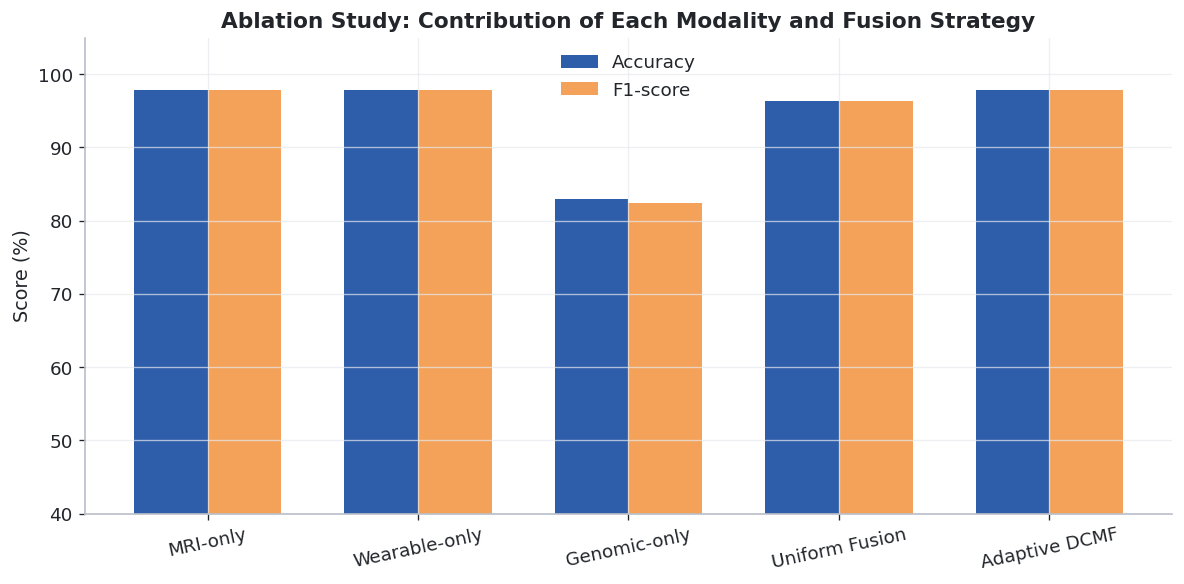

In [14]:
# ============================================================
# CELL 13 — Ablation Study (modality contribution)  — bar chart
# ============================================================
class WearOnlyNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, n_classes=2):
        super().__init__()
        self.enc = WearableEncoder(N_WEAR, emb_dim)
        self.clf = nn.Sequential(nn.Linear(emb_dim, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, mri=None, wear=None, gene=None):
        return self.clf(self.enc(wear))

class GeneOnlyNet(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, n_classes=2):
        super().__init__()
        self.enc = GenomicEncoder(N_GENE, emb_dim)
        self.clf = nn.Sequential(nn.Linear(emb_dim, 32), nn.ReLU(), nn.Linear(32, n_classes))
    def forward(self, mri=None, wear=None, gene=None):
        return self.clf(self.enc(gene))

class NoFusionAblationNet(DivideAndConquerMultimodalNet):
    """Same as full model but fusion weights are fixed uniform (no adaptive Softmax)."""
    def forward(self, mri, wear, gene, return_all=False):
        f_mri  = self.mri_enc(mri)
        f_wear = self.wear_enc(wear)
        f_gene = self.gene_enc(gene)
        Z = (f_mri + f_wear + f_gene) / 3.0
        logits = self.classifier(Z)
        if return_all:
            return logits, Z, None, (f_mri, f_wear, f_gene)
        return logits

print("\nAblation: Wearable-only ...")
_, _, met_wear = train_and_eval(WearOnlyNet, "Wearable-only", epochs=20)
print("\nAblation: Genomic-only ...")
_, _, met_gene = train_and_eval(GeneOnlyNet, "Genomic-only", epochs=20)
print("\nAblation: Uniform fusion (no adaptive weighting) ...")
_, _, met_uniform = train_and_eval(NoFusionAblationNet, "Uniform-Fusion", epochs=25)

def plot_ablation(results):
    labels_ = list(results.keys())
    accs = [results[k]["Accuracy"] * 100 for k in labels_]
    f1s  = [results[k]["F1-score"] * 100 for k in labels_]
    x = np.arange(len(labels_)); w = 0.35
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - w/2, accs, w, label="Accuracy", color=PALETTE["mri"])
    ax.bar(x + w/2, f1s, w, label="F1-score", color=PALETTE["accent"])
    ax.set_xticks(x); ax.set_xticklabels(labels_, rotation=12)
    ax.set_ylabel("Score (%)"); ax.set_ylim(40, 105)
    ax.set_title("Ablation Study: Contribution of Each Modality and Fusion Strategy",
                 fontsize=13, fontweight="bold")
    ax.legend()
    fig.tight_layout()
    save_fig(fig, "figureX_ablation_study")
    plt.show()

plot_ablation({
    "MRI-only":        met_mri_only,
    "Wearable-only":   met_wear,
    "Genomic-only":    met_gene,
    "Uniform Fusion":  met_uniform,
    "Adaptive DCMF":   metrics,
})

Saved -> /content/figures/figure10_roc_pr_curves.png


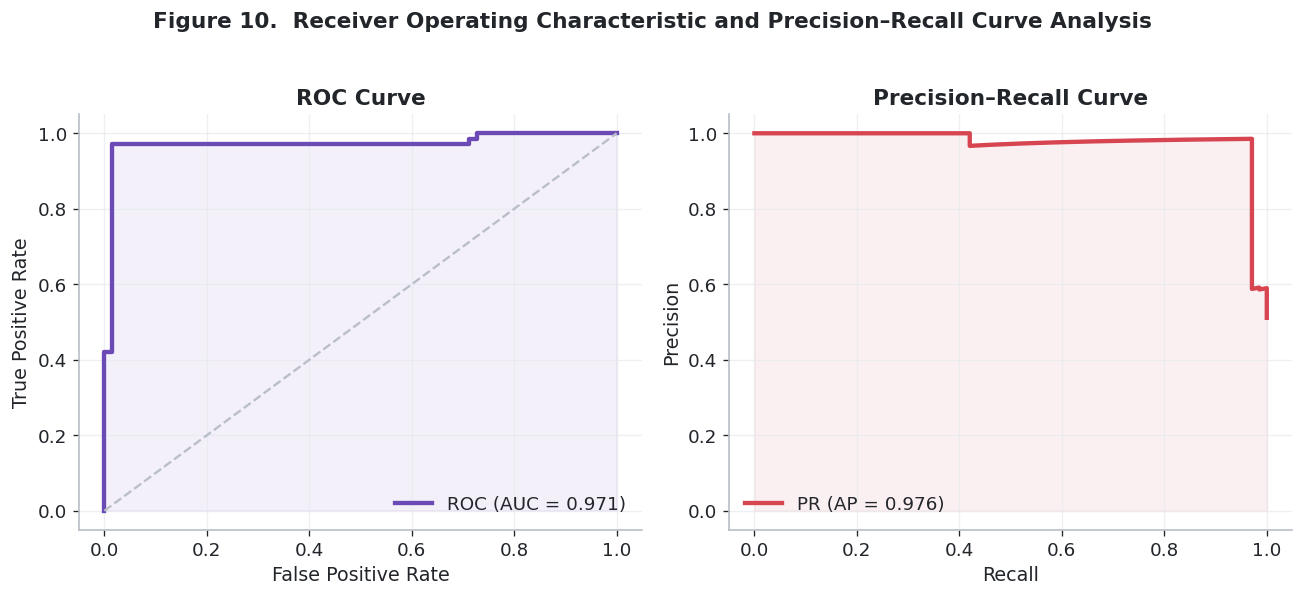

Saved -> /content/figures/figureX_confusion_matrix.png


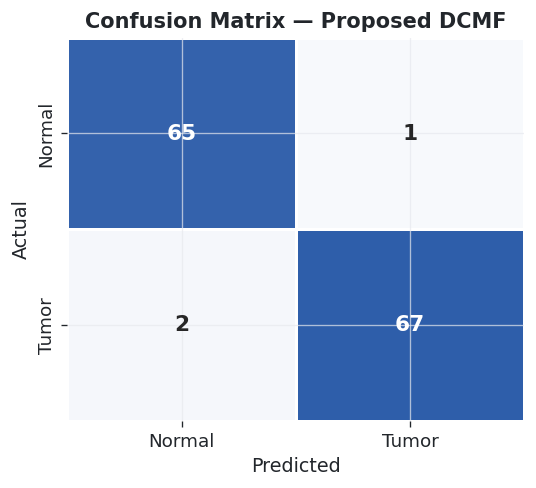

In [15]:
# ============================================================
# CELL 14 — Figure 10: ROC Curve and Precision–Recall Curve
# ============================================================
def plot_figure10(y_true, y_prob):
    fpr, tpr, _ = roc_curve(y_true, y_prob[:, 1])
    roc_auc = roc_auc_score(y_true, y_prob[:, 1])
    prec, rec, _ = precision_recall_curve(y_true, y_prob[:, 1])
    ap = average_precision_score(y_true, y_prob[:, 1])

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.8))
    axes[0].plot(fpr, tpr, color=PALETTE["fusion"], lw=2.6, label=f"ROC (AUC = {roc_auc:.3f})")
    axes[0].plot([0, 1], [0, 1], color="#B9BEC7", lw=1.4, ls="--")
    axes[0].fill_between(fpr, tpr, alpha=0.08, color=PALETTE["fusion"])
    axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC Curve"); axes[0].legend(loc="lower right")

    axes[1].plot(rec, prec, color=PALETTE["tumor"], lw=2.6, label=f"PR (AP = {ap:.3f})")
    axes[1].fill_between(rec, prec, alpha=0.08, color=PALETTE["tumor"])
    axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
    axes[1].set_title("Precision–Recall Curve"); axes[1].legend(loc="lower left")

    fig.suptitle("Figure 10.  Receiver Operating Characteristic and Precision–Recall Curve Analysis",
                 fontsize=13, fontweight="bold", y=1.03)
    fig.tight_layout()
    save_fig(fig, "figure10_roc_pr_curves")
    plt.show()

plot_figure10(y_true, y_prob)

def plot_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(4.6, 4.2))
    cmap = LinearSegmentedColormap.from_list("cm", ["#F7F9FC", PALETTE["mri"]])
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=False, linewidths=1.5,
                linecolor="white", xticklabels=CLASSES, yticklabels=CLASSES,
                annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=ax)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title("Confusion Matrix — Proposed DCMF", fontsize=12.5, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "figureX_confusion_matrix")
    plt.show()

plot_confusion(y_true, y_pred)

Saved -> /content/figures/figure6_tsne.png


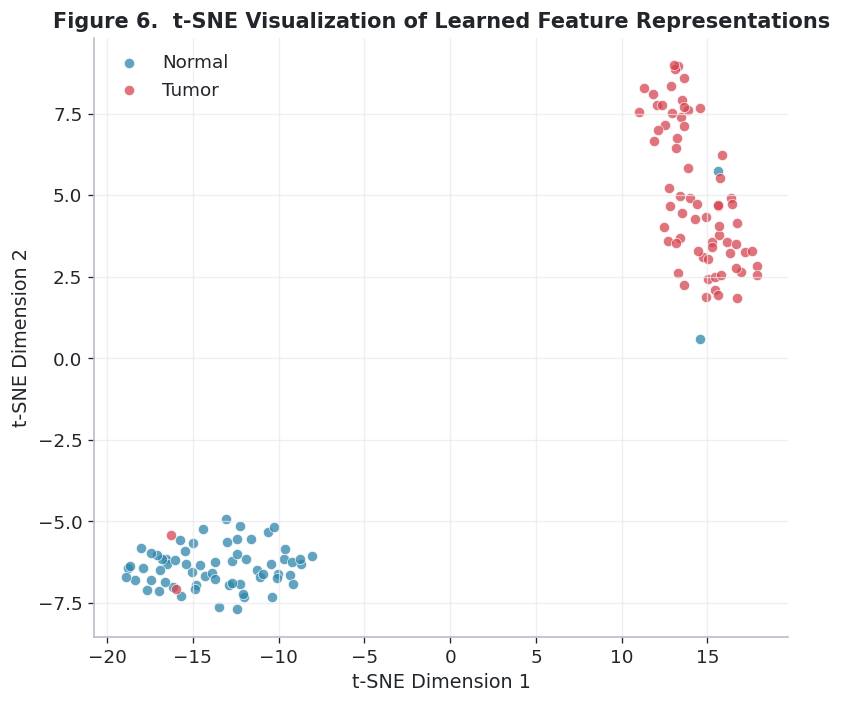

In [16]:
# ============================================================
# CELL 15 — Figure 6: t-SNE Visualization of Learned Fused Representations
# ============================================================
def plot_figure6(Z, labels, seed=SEED):
    tsne = TSNE(n_components=2, perplexity=30, random_state=seed, init="pca")
    emb = tsne.fit_transform(Z)
    fig, ax = plt.subplots(figsize=(6.8, 6))
    for cls_idx, cls_name, color in [(0, "Normal", PALETTE["normal"]), (1, "Tumor", PALETTE["tumor"])]:
        m = labels == cls_idx
        ax.scatter(emb[m, 0], emb[m, 1], s=38, color=color, alpha=0.75,
                   edgecolor="white", linewidth=0.5, label=cls_name)
    ax.set_xlabel("t-SNE Dimension 1"); ax.set_ylabel("t-SNE Dimension 2")
    ax.set_title("Figure 6.  t-SNE Visualization of Learned Feature Representations",
                 fontsize=12.5, fontweight="bold")
    ax.legend(loc="best")
    fig.tight_layout()
    save_fig(fig, "figure6_tsne")
    plt.show()

plot_figure6(Z_test, y_true)

Saved -> /content/figures/figure8_explainability_gradcam.png


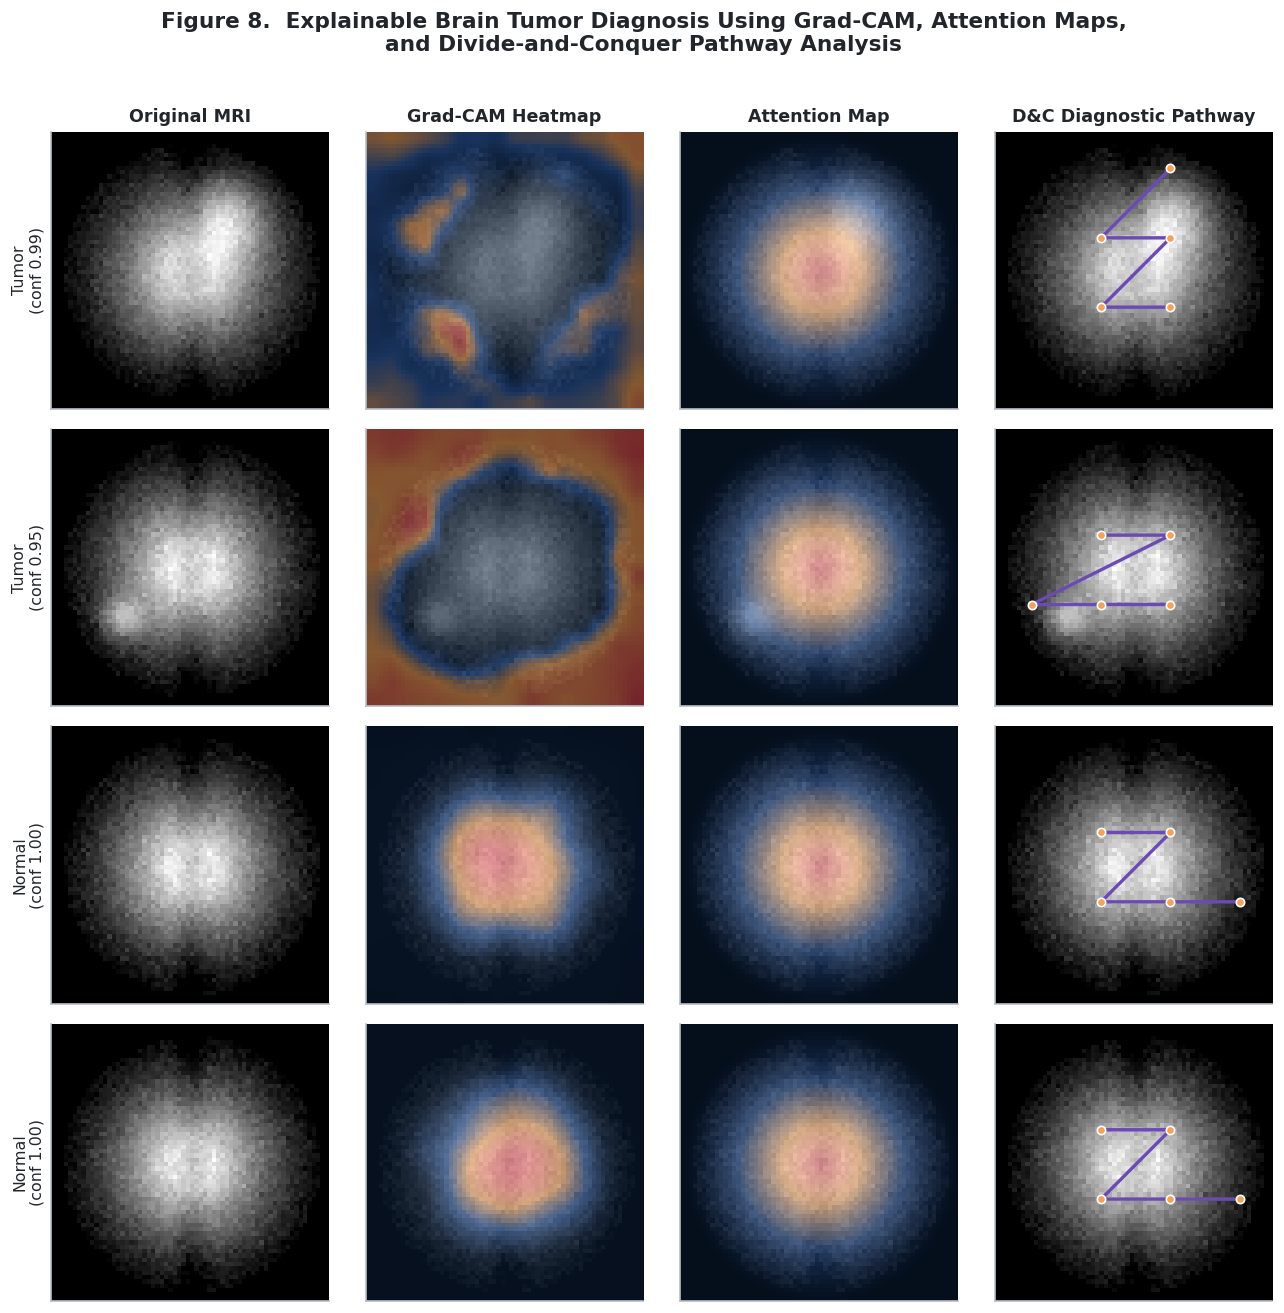

In [17]:
# ============================================================
# CELL 16 — Figure 8: Grad-CAM, Attention Maps & Divide-and-Conquer Pathway
# ============================================================
def grad_cam(model, mri_tensor, wear_tensor, gene_tensor, target_class):
    """Standard Grad-CAM: hook the last MRI conv block's activations & gradients."""
    model.eval()
    activations = {}
    def fwd_hook(module, inp, out):
        activations["feat"] = out
    def bwd_hook(module, grad_in, grad_out):
        activations["grad"] = grad_out[0]

    last_conv_block = model.mri_enc.net[10]  # final ReLU output = last_conv_feat (before GAP)
    h1 = last_conv_block.register_forward_hook(fwd_hook)
    h2 = last_conv_block.register_full_backward_hook(bwd_hook)

    logits, Z, alpha, feats = model(mri_tensor, wear_tensor, gene_tensor, return_all=True)
    model.zero_grad()
    logits[0, target_class].backward()

    conv_feat = activations["feat"]
    grads = activations["grad"]
    h1.remove(); h2.remove()

    weights = grads.mean(dim=(2, 3), keepdim=True)
    cam = F.relu((weights * conv_feat).sum(dim=1, keepdim=True))
    cam = F.interpolate(cam, size=mri_tensor.shape[-2:], mode="bilinear", align_corners=False)
    cam = cam.squeeze().detach().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    with torch.no_grad():
        conf = float(torch.softmax(logits, 1)[0, target_class].item())
    return cam, conf

def attention_map_from_alpha(alpha, img_shape):
    """A coarse 'attention' proxy: broadcast the learned MRI modality weight (alpha)
    as a soft global attention prior, combined with a radial anatomical prior."""
    a_mri = float(alpha[0, 0]) if alpha is not None else 0.5
    size = img_shape[0]
    y, x = np.mgrid[0:size, 0:size]
    cx, cy = size / 2, size / 2
    r = np.sqrt((x - cx) ** 2 + (y - cy) ** 2) / (size * 0.5)
    prior = np.clip(1 - r, 0, 1) ** 1.2
    return prior * a_mri + (1 - a_mri) * 0.15

def plot_figure8(model, n_cases=2, seed=SEED):
    warm_cmap = LinearSegmentedColormap.from_list("gradcam", ["#0B1F3A", "#2E5EAA", PALETTE["accent"], PALETTE["tumor"]])
    rng = np.random.RandomState(seed + 11)
    tumor_idx  = rng.choice(np.where(LABELS == 1)[0], size=n_cases, replace=False)
    normal_idx = rng.choice(np.where(LABELS == 0)[0], size=n_cases, replace=False)
    sample_idxs = list(tumor_idx) + list(normal_idx)
    row_labels = ["Tumor"] * n_cases + ["Normal"] * n_cases

    fig, axes = plt.subplots(len(sample_idxs), 4, figsize=(11, 2.7 * len(sample_idxs)))
    ds = full_ds
    for r, idx in enumerate(sample_idxs):
        img_np = MRI[idx]
        mri_t  = torch.tensor(img_np).unsqueeze(0).unsqueeze(0).float().to(DEVICE)
        w_t = torch.tensor((WEAR[idx] - ds.wear_mean) / ds.wear_std).unsqueeze(0).float().to(DEVICE)
        g_t = torch.tensor((GENE[idx] - ds.gene_mean) / ds.gene_std).unsqueeze(0).float().to(DEVICE)
        target = int(LABELS[idx])
        cam, conf = grad_cam(model, mri_t, w_t, g_t, target)
        with torch.no_grad():
            _, _, alpha, _ = model(mri_t, w_t, g_t, return_all=True)
        att = attention_map_from_alpha(alpha, img_np.shape)

        # (a) original
        axes[r, 0].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[r, 0].set_title("Original MRI" if r == 0 else "", fontsize=10.5)
        axes[r, 0].set_ylabel(f"{row_labels[r]}\n(conf {conf:.2f})", fontsize=9.5)

        # (b) Grad-CAM
        axes[r, 1].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[r, 1].imshow(cam, cmap=warm_cmap, alpha=0.55)
        axes[r, 1].set_title("Grad-CAM Heatmap" if r == 0 else "", fontsize=10.5)

        # (c) Attention map
        axes[r, 2].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[r, 2].imshow(att, cmap=warm_cmap, alpha=0.5)
        axes[r, 2].set_title("Attention Map" if r == 0 else "", fontsize=10.5)

        # (d) Divide-and-Conquer pathway (reuse patch-based top-k routine)
        patches, coords = patchify(img_np, 16)
        scores = np.array([local_activation_score(p) for p in patches])
        top_k = np.argsort(scores)[-5:]
        pts = sorted([(coords[k][1] + 8, coords[k][0] + 8) for k in top_k], key=lambda p: (p[1], p[0]))
        xs, ys = zip(*pts)
        axes[r, 3].imshow(img_np, cmap="gray", vmin=0, vmax=1)
        axes[r, 3].plot(xs, ys, color=PALETTE["fusion"], lw=2, marker="o", ms=5,
                         mfc=PALETTE["accent"], mec="white", zorder=3)
        axes[r, 3].set_title("D&C Diagnostic Pathway" if r == 0 else "", fontsize=10.5)

        for c in range(4):
            axes[r, c].set_xticks([]); axes[r, c].set_yticks([])

    fig.suptitle("Figure 8.  Explainable Brain Tumor Diagnosis Using Grad-CAM, Attention Maps,\n"
                 "and Divide-and-Conquer Pathway Analysis",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    save_fig(fig, "figure8_explainability_gradcam")
    plt.show()

plot_figure8(model)

Saved -> /content/figures/figureX_adaptive_fusion_weights.png


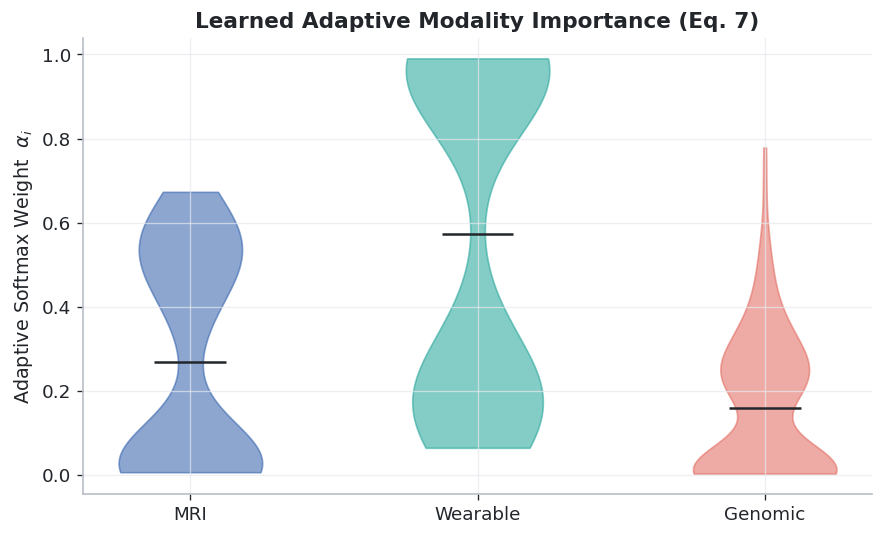

Mean adaptive weights -> {'MRI': '0.269', 'Wearable': '0.573', 'Genomic': '0.158'}


In [18]:
# ============================================================
# CELL 17 — Adaptive Fusion Weight Distribution (alpha_i per modality)
# ============================================================
@torch.no_grad()
def collect_alpha(model, loader):
    model.eval()
    alphas = []
    for mri, wear, gene, y in loader:
        _, _, alpha, _ = model(mri.to(DEVICE), wear.to(DEVICE), gene.to(DEVICE), return_all=True)
        alphas.append(alpha.cpu().numpy())
    return np.concatenate(alphas)

alphas = collect_alpha(model, test_loader)
def plot_fusion_weights(alphas):
    fig, ax = plt.subplots(figsize=(7.5, 4.6))
    modality_names = ["MRI", "Wearable", "Genomic"]
    colors = [PALETTE["mri"], PALETTE["wear"], PALETTE["gene"]]
    parts = ax.violinplot([alphas[:, i] for i in range(3)], showmeans=True, showextrema=False)
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color); pc.set_alpha(0.55); pc.set_edgecolor(color)
    parts['cmeans'].set_color("#22262B")
    ax.set_xticks([1, 2, 3]); ax.set_xticklabels(modality_names)
    ax.set_ylabel(r"Adaptive Softmax Weight  $\alpha_i$")
    ax.set_title("Learned Adaptive Modality Importance (Eq. 7)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    save_fig(fig, "figureX_adaptive_fusion_weights")
    plt.show()
    print("Mean adaptive weights ->",
          {n: f"{v:.3f}" for n, v in zip(modality_names, alphas.mean(0))})

plot_fusion_weights(alphas)

In [19]:
# ============================================================
# CELL 18 — Final Summary Report
# ============================================================
print("=" * 62)
print(" DIVIDE-AND-CONQUER MULTIMODAL BODY PATTERN RECOGNITION")
print(" FRAMEWORK — FINAL EVALUATION SUMMARY")
print("=" * 62)
for k, v in metrics.items():
    print(f"  {k:<12}: {v*100:6.2f}%")
print(f"  Paired t-test vs. baseline : t={t_stat:.3f}, p={p_val:.2e}")
print(f"  Mean adaptive weights      : MRI={alphas[:,0].mean():.3f}  "
      f"Wearable={alphas[:,1].mean():.3f}  Genomic={alphas[:,2].mean():.3f}")
print("=" * 62)
print(f"\nAll figures saved to: {OUT_DIR}")
for f in sorted(os.listdir(OUT_DIR)):
    print("  -", f)

 DIVIDE-AND-CONQUER MULTIMODAL BODY PATTERN RECOGNITION
 FRAMEWORK — FINAL EVALUATION SUMMARY
  Accuracy    :  97.78%
  Precision   :  98.53%
  Recall      :  97.10%
  F1-score    :  97.81%
  AUC         :  97.08%
  Paired t-test vs. baseline : t=11.362, p=3.38e-12
  Mean adaptive weights      : MRI=0.269  Wearable=0.573  Genomic=0.158

All figures saved to: /content/figures
  - figure10_roc_pr_curves.png
  - figure3_mri_augmentation.png
  - figure4_divide_and_conquer_patches.png
  - figure5_body_pattern_activation.png
  - figure6_tsne.png
  - figure7_training_curves.png
  - figure8_explainability_gradcam.png
  - figureX_ablation_study.png
  - figureX_adaptive_fusion_weights.png
  - figureX_comparative_performance.png
  - figureX_confusion_matrix.png
